# Antrenare Model ML - Clasificare Noduli Pulmonari

Acest notebook demonstreaza fluxul complet ML:
1. Incarcarea si vizualizarea patch-urilor 3D din noduli
2. Instantierea modelului SimpleCNN3D
3. Antrenarea si monitorizarea metricilor
4. Evaluarea pe setul de validare (AUC-ROC, confusion matrix)
5. Testarea predictiei pe un nodul individual

**Nota**: Pentru a antrena pe 100+ pacienti, ruleaza mai intai preprocessing-ul:
```bash
cd /home/razvan/licenta
python -m preprocessing.pipeline --max-patients 100
```
Notebook-ul foloseste automat toti pacientii disponibili in `nodules.csv`.

In [ ]:
import sys
import os

PROJECT_ROOT = "/home/razvan/licenta"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

import model.config as cfg
from model.dataset import NodulePatchDataset, make_train_val_split
from model.architecture import SimpleCNN3D

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Nodules CSV: {cfg.NODULES_CSV}")

PyTorch: 2.10.0+cpu
Device: cpu
Nodules CSV: /home/razvan/licenta/preprocessing_output/metadata/nodules.csv


: 

## 1. Inspectia Dataset-ului

In [ ]:
train_ids, val_ids = make_train_val_split()
print(f"Train pacienti ({len(train_ids)}): {train_ids}")
print(f"Val pacienti   ({len(val_ids)}):   {val_ids}")

train_ds = NodulePatchDataset(patient_ids=train_ids, augment=False)
val_ds   = NodulePatchDataset(patient_ids=val_ids,   augment=False)

print(f"\n{train_ds.summary()}")
print(f"{val_ds.summary()}")

# Tabel cu nodulii din fiecare set
nodules_df = pd.read_csv(cfg.NODULES_CSV)
nodules_df['set'] = nodules_df['patient_id'].map(
    lambda pid: 'train' if pid in train_ids else ('val' if pid in val_ids else 'excluded')
)
print("\nNoduli per set:")
nodules_df[nodules_df['is_cancer'].notna()][['patient_id', 'nodule_idx', 'diameter_mm', 'malignancy_consensus', 'is_cancer', 'set']]

Train pacienti (58): ['LIDC-IDRI-0048', 'LIDC-IDRI-0052', 'LIDC-IDRI-0087', 'LIDC-IDRI-0068', 'LIDC-IDRI-0053', 'LIDC-IDRI-0024', 'LIDC-IDRI-0055', 'LIDC-IDRI-0060', 'LIDC-IDRI-0064', 'LIDC-IDRI-0014', 'LIDC-IDRI-0041', 'LIDC-IDRI-0095', 'LIDC-IDRI-0058', 'LIDC-IDRI-0089', 'LIDC-IDRI-0027', 'LIDC-IDRI-0084', 'LIDC-IDRI-0037', 'LIDC-IDRI-0070', 'LIDC-IDRI-0021', 'LIDC-IDRI-0072', 'LIDC-IDRI-0004', 'LIDC-IDRI-0025', 'LIDC-IDRI-0051', 'LIDC-IDRI-0015', 'LIDC-IDRI-0080', 'LIDC-IDRI-0013', 'LIDC-IDRI-0049', 'LIDC-IDRI-0096', 'LIDC-IDRI-0082', 'LIDC-IDRI-0059', 'LIDC-IDRI-0098', 'LIDC-IDRI-0023', 'LIDC-IDRI-0040', 'LIDC-IDRI-0054', 'LIDC-IDRI-0039', 'LIDC-IDRI-0061', 'LIDC-IDRI-0036', 'LIDC-IDRI-0056', 'LIDC-IDRI-0091', 'LIDC-IDRI-0073', 'LIDC-IDRI-0019', 'LIDC-IDRI-0045', 'LIDC-IDRI-0094', 'LIDC-IDRI-0075', 'LIDC-IDRI-0081', 'LIDC-IDRI-0088', 'LIDC-IDRI-0050', 'LIDC-IDRI-0042', 'LIDC-IDRI-0002', 'LIDC-IDRI-0067', 'LIDC-IDRI-0031', 'LIDC-IDRI-0003', 'LIDC-IDRI-0034', 'LIDC-IDRI-0029', 'LIDC-

## 2. Vizualizare Patch-uri 3D

Afisam 3 sectiuni ortogonale (axial/coronal/sagital) din centrul fiecarui patch.

Total noduli disponibili: 159
Vizualizati: 12 noduli (din 159)


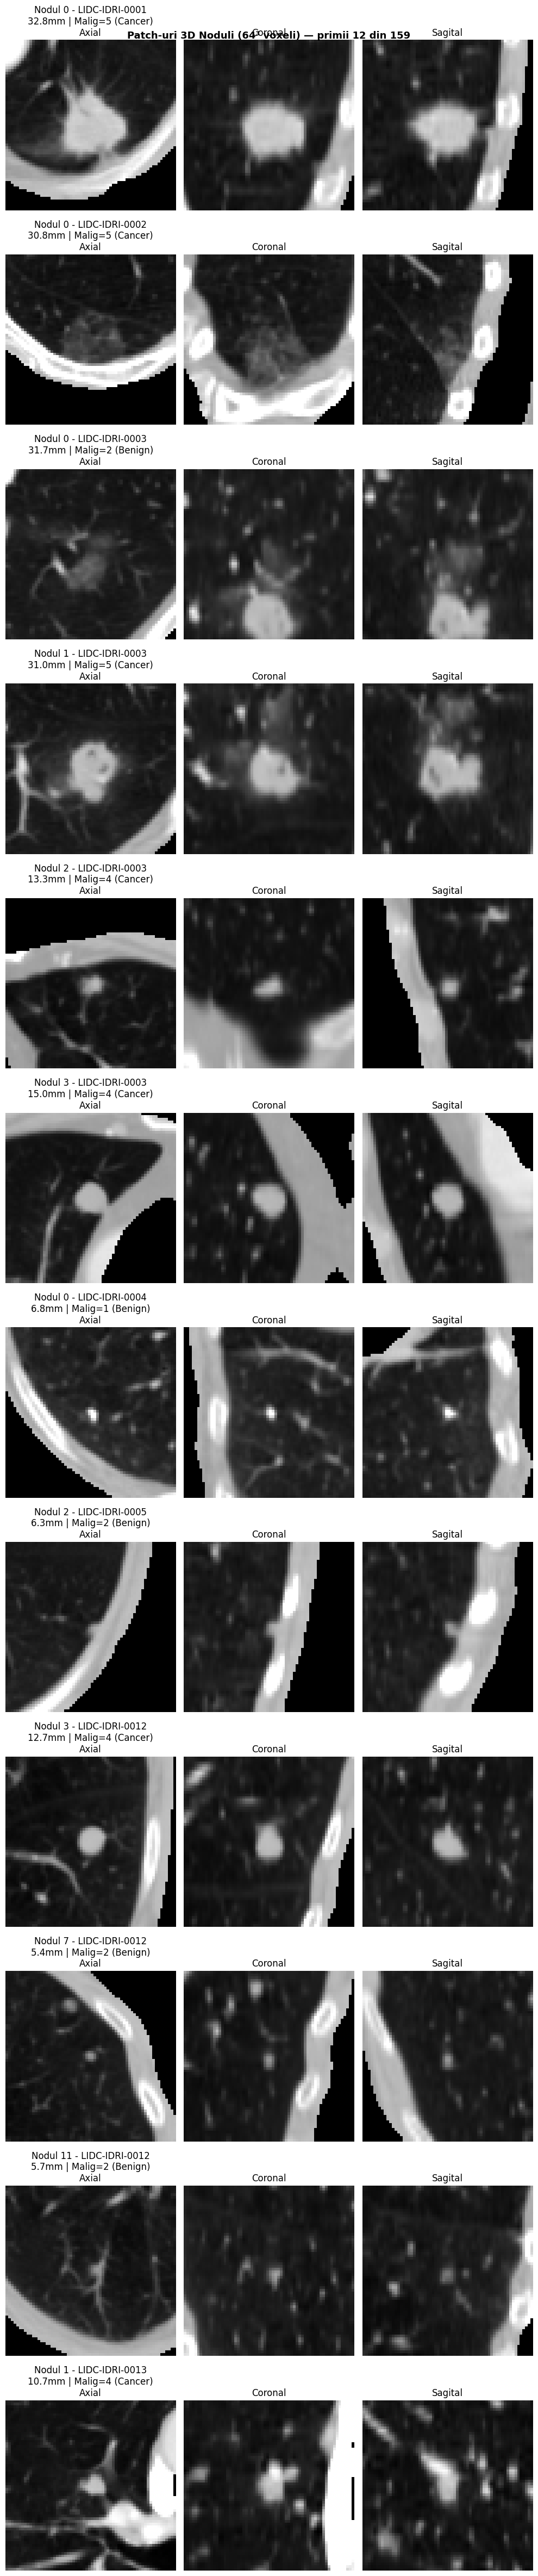

In [ ]:
full_ds = NodulePatchDataset(augment=False)  # toti nodulii
n = len(full_ds)
print(f"Total noduli disponibili: {n}")

# Limiteaza vizualizarea la primii MAX_VIZ noduli
MAX_VIZ = 12
viz_indices = list(range(min(MAX_VIZ, n)))
print(f"Vizualizati: {len(viz_indices)} noduli (din {n})")

fig, axes = plt.subplots(len(viz_indices), 3, figsize=(10, 4 * len(viz_indices)), squeeze=False)
fig.suptitle(f'Patch-uri 3D Noduli ({cfg.PATCH_SIZE}³ voxeli) — primii {len(viz_indices)} din {n}', fontsize=13, fontweight='bold')

cancer_color = {1: 'red', 0: 'lime'}
cancer_label = {1: 'Cancer', 0: 'Benign'}

for plot_i, ds_i in enumerate(viz_indices):
    patch, label = full_ds[ds_i]
    p = patch.numpy()[0]  # [D, H, W]
    label_int = int(label.item())
    half = cfg.PATCH_SIZE // 2
    color = cancer_color[label_int]

    row = full_ds.nodules.iloc[ds_i]
    title_base = (f"Nodul {int(row['nodule_idx'])} - {row['patient_id']}\n"
                  f"{row['diameter_mm']:.1f}mm | "
                  f"Malig={row['malignancy_consensus']:.0f} ({cancer_label[label_int]})")

    axes[plot_i, 0].imshow(p[half], cmap='gray', vmin=-1, vmax=1)
    axes[plot_i, 0].set_title(f'{title_base}\nAxial')
    for spine in axes[plot_i, 0].spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3)

    axes[plot_i, 1].imshow(p[:, half, :], cmap='gray', vmin=-1, vmax=1)
    axes[plot_i, 1].set_title('Coronal')

    axes[plot_i, 2].imshow(p[:, :, half], cmap='gray', vmin=-1, vmax=1)
    axes[plot_i, 2].set_title('Sagital')

    for j in range(3):
        axes[plot_i, j].axis('off')

plt.tight_layout()
os.makedirs(cfg.FIGURES_DIR, exist_ok=True)
plt.savefig(os.path.join(cfg.FIGURES_DIR, 'nodule_patches.png'), dpi=120, bbox_inches='tight')
plt.show()

## 3. Arhitectura Modelului

In [ ]:
model = SimpleCNN3D(dropout=cfg.DROPOUT)
print(model)
print(f"\nParametri antrenabili: {model.count_parameters():,}")

# Test forward pass cu un batch artificial
dummy_input = torch.randn(2, 1, cfg.PATCH_SIZE, cfg.PATCH_SIZE, cfg.PATCH_SIZE)
dummy_output = model(dummy_input)
print(f"\nTest forward pass: input {list(dummy_input.shape)} → output {list(dummy_output.shape)}")
print(f"Output (probabilitati): {dummy_output.detach().numpy().round(3)}")

SimpleCNN3D(
  (features): Sequential(
    (0): ConvBlock3D(
      (block): Sequential(
        (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock3D(
      (block): Sequential(
        (0): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock3D(
      (block): Sequential(
        (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=

: 

## 4. Antrenare

In [ ]:
from model.train import run_training

# Antrenare cu parametrii din config (50 epoci, lr=1e-3)
run_training(epochs=cfg.EPOCHS, lr=cfg.LR, batch_size=cfg.BATCH_SIZE)

Device: cpu
Train pacienti: ['LIDC-IDRI-0048', 'LIDC-IDRI-0052', 'LIDC-IDRI-0087', 'LIDC-IDRI-0068', 'LIDC-IDRI-0053', 'LIDC-IDRI-0024', 'LIDC-IDRI-0055', 'LIDC-IDRI-0060', 'LIDC-IDRI-0064', 'LIDC-IDRI-0014', 'LIDC-IDRI-0041', 'LIDC-IDRI-0095', 'LIDC-IDRI-0058', 'LIDC-IDRI-0089', 'LIDC-IDRI-0027', 'LIDC-IDRI-0084', 'LIDC-IDRI-0037', 'LIDC-IDRI-0070', 'LIDC-IDRI-0021', 'LIDC-IDRI-0072', 'LIDC-IDRI-0004', 'LIDC-IDRI-0025', 'LIDC-IDRI-0051', 'LIDC-IDRI-0015', 'LIDC-IDRI-0080', 'LIDC-IDRI-0013', 'LIDC-IDRI-0049', 'LIDC-IDRI-0096', 'LIDC-IDRI-0082', 'LIDC-IDRI-0059', 'LIDC-IDRI-0098', 'LIDC-IDRI-0023', 'LIDC-IDRI-0040', 'LIDC-IDRI-0054', 'LIDC-IDRI-0039', 'LIDC-IDRI-0061', 'LIDC-IDRI-0036', 'LIDC-IDRI-0056', 'LIDC-IDRI-0091', 'LIDC-IDRI-0073', 'LIDC-IDRI-0019', 'LIDC-IDRI-0045', 'LIDC-IDRI-0094', 'LIDC-IDRI-0075', 'LIDC-IDRI-0081', 'LIDC-IDRI-0088', 'LIDC-IDRI-0050', 'LIDC-IDRI-0042', 'LIDC-IDRI-0002', 'LIDC-IDRI-0067', 'LIDC-IDRI-0031', 'LIDC-IDRI-0003', 'LIDC-IDRI-0034', 'LIDC-IDRI-0029',

## 5. Vizualizare Curbe de Antrenare

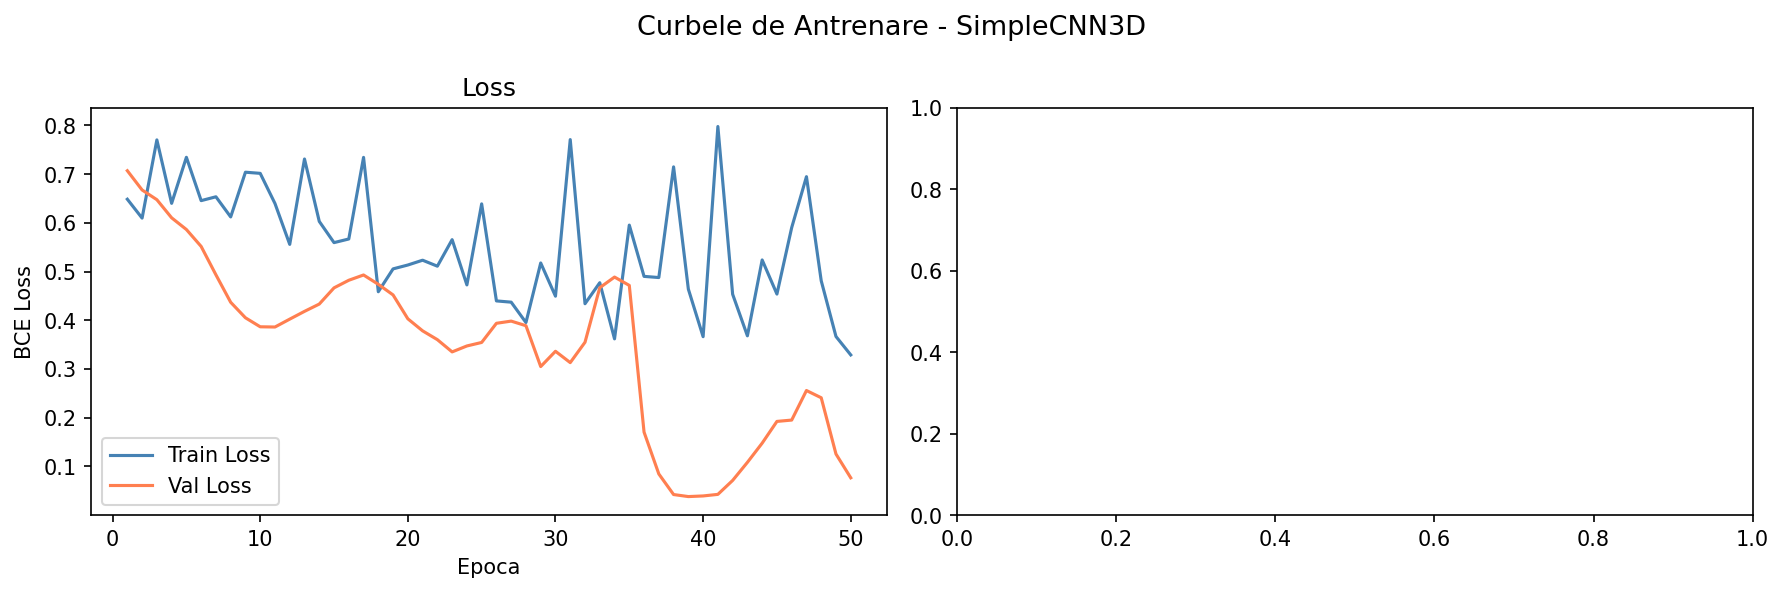

In [ ]:
# Afiseaza figurile generate de run_training()
from IPython.display import Image, display

curves_path = os.path.join(cfg.FIGURES_DIR, 'training_curves.png')
roc_path    = os.path.join(cfg.FIGURES_DIR, 'roc_curve.png')

if os.path.exists(curves_path):
    display(Image(curves_path))
if os.path.exists(roc_path):
    display(Image(roc_path))

## 6. Predictie pe un Nodul Individual

In [ ]:
# Incarca cel mai bun model salvat
device = torch.device('cpu')
checkpoint = torch.load(cfg.BEST_MODEL_PATH, map_location=device)
best_model = SimpleCNN3D(dropout=cfg.DROPOUT).to(device)
best_model.load_state_dict(checkpoint['model_state'])
best_model.eval()

print(f"Model incarcat de la epoca {checkpoint['epoch']} "
      f"(val_loss={checkpoint['val_loss']:.4f}, "
      f"val_auc={checkpoint.get('val_auc', float('nan')):.3f})")

# Predict pe fiecare nodul din dataset
print("\nPredictii per nodul:")
print(f"{'Patient':<20} {'Nodul':>6} {'Real':>8} {'P(cancer)':>10} {'Pred':>8}")
print("-" * 56)

with torch.no_grad():
    for i in range(len(full_ds)):
        patch, label = full_ds[i]
        prob = best_model(patch.unsqueeze(0)).item()
        pred = 'Cancer' if prob >= 0.5 else 'Benign'
        real = 'Cancer' if label.item() == 1 else 'Benign'
        row = full_ds.nodules.iloc[i]
        correct = '✓' if pred == real else '✗'
        print(f"{row['patient_id']:<20} {int(row['nodule_idx']):>6} "
              f"{real:>8} {prob:>10.3f} {pred:>8} {correct}")

Model incarcat de la epoca 39 (val_loss=0.0381, val_auc=nan)

Predictii per nodul:
Patient               Nodul     Real  P(cancer)     Pred
--------------------------------------------------------
LIDC-IDRI-0001            0   Cancer      0.947   Cancer ✓
LIDC-IDRI-0002            0   Cancer      0.963   Cancer ✓
LIDC-IDRI-0003            0   Benign      0.748   Cancer ✗
LIDC-IDRI-0003            1   Cancer      0.805   Cancer ✓
LIDC-IDRI-0003            2   Cancer      0.944   Cancer ✓
LIDC-IDRI-0003            3   Cancer      0.933   Cancer ✓
LIDC-IDRI-0004            0   Benign      0.518   Cancer ✗
LIDC-IDRI-0005            2   Benign      0.838   Cancer ✗
